# Live multisim systematics (sel_mup weights)

Walk a directory of final-selection ``.df`` files that carry systematic universe
weights (e.g. Flux ``sel_mup-wgts_flux-corrected``), accumulate CV + universe
rate histograms for the cross-section measurement variables, and refresh a
**live multi-panel** as statistics grow — same interactive pattern as
``event_selection.ipynb``.

Files are loaded in batches of ``FILES_PER_BATCH`` (default **200**) via
``pyanalib.split_df_helpers.load_dfs``, concatenated, then processed once per
batch (not one file at a time).

**Flux / G4 knobs:** each knob is histogrammed separately; a **product-of-knobs
total** (same universe index) is also accumulated by default.

Each panel row (per variable):

1. **Product-total** universe overlays (light, ``alpha=0.05``) + **CV in bold black**
2. Covariance matrix (from product total)
3. Correlation matrix (from product total)
4. Fractional uncertainty: **each knob** + **indep. fractional sum** + **product total**

Saved under ``work_dir`` on every refresh:

* ``accumulated_histcounts.pkl`` — raw ``acc`` histcounts **and** derived ``analysis``
  packs (per-knob / indep sum / product)
* ``plots/live_panel_latest.png`` (+ ``live_panel_filesNNNN.png`` snapshots)

The last section reloads that pickle and re-plots.


In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from os import path, makedirs
from datetime import datetime
from pathlib import Path
import glob
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")  # absolute path for EAF

from analysis_village.numucc_1p0pi.utils import (
    plot_univ_hists,
    plot_heatmap,
    plot_frac_unc,
)
from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE
from analysis_village.numucc_1p0pi.syst_multisim_live import (
    LiveMultisimConfig,
    UNIV_ALPHA,
    default_plot_var_names,
    default_work_dir,
    discover_df_files,
    knobs_for_syst,
    load_payload,
    make_accumulation_panel,
    packs_from_payload,
    run_live_accumulate,
    var_configs_from_payload,
    draw_univ_hists_on_ax,
    draw_frac_unc_on_ax,
    draw_heatmap_on_ax,
    frac_series_from_analysis,
    frac_unc_from_pack,
)

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.style.use("presentation.mplstyle")
print(f"universe overlay alpha = {UNIV_ALPHA} (5%)")

universe overlay alpha = 0.05 (5%)


In [25]:
UNIV_ALPHA = 0.4

## Config

In [26]:
# ===== input dfs =====
# Directory of selected sel_mup events with systematic weights.
DF_DIR = (
    "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/"
    "2026_09_03_022028__sel_mup-wgts_flux-corrected"
)

SYST_NAME = "Flux"          # "Flux" | "G4" | "MCstat"
FLUX_KNOB_GROUPS = "all"    # Flux only: "all" | "beam" | "hadron" | "xsec" | CSV

# ===== live / partial-run knobs =====
MAX_FILES = None              # int, or None for all *.df in DF_DIR
FILES_PER_BATCH = 400       # concat this many files via split_df_helpers.load_dfs, then process
N_UNIVERSE = 1000            # files may store up to 1000; cap for interactive speed
UPDATE_EVERY_N_FILES = 400  # refresh panel every N files (default = one batch)
SHOW_IN_NOTEBOOK = True
ACCUMULATE_TOTAL = True     # default: product-of-knobs total for every accumulated var

# Variables shown on the live panel (histogram counts are filled for these by default).
# Set ACCUMULATE_VAR_NAMES to a larger list for a fuller dump.
PLOT_VAR_NAMES = list(default_plot_var_names())
ACCUMULATE_VAR_NAMES = None  # None → same as PLOT_VAR_NAMES

today_str = datetime.now().strftime("%Y%m%d")
work_dir = path.join(PLOTS_BASE, f"systematics-multisim-live-{SYST_NAME}-{today_str}")
plots_dir = path.join(work_dir, "plots")

n_df = len(glob.glob(path.join(DF_DIR, "*.df")))
print(f"DF_DIR = {DF_DIR}")
print(f"  *.df files available: {n_df}")
print(f"  MAX_FILES = {MAX_FILES}  FILES_PER_BATCH = {FILES_PER_BATCH}  N_UNIVERSE = {N_UNIVERSE}")
print(f"  knobs ({SYST_NAME}): {knobs_for_syst(SYST_NAME, FLUX_KNOB_GROUPS)}")
print(f"  work_dir = {work_dir}")


DF_DIR = /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_03_022028__sel_mup-wgts_flux-corrected
  *.df files available: 4000
  MAX_FILES = None  FILES_PER_BATCH = 400  N_UNIVERSE = 1000
  knobs (Flux): ('expskin_Flux', 'horncurrent_Flux', 'kminus_Flux', 'kplus_Flux', 'kzero_Flux', 'nucleoninexsec_Flux', 'nucleonqexsec_Flux', 'nucleontotxsec_Flux', 'piminus_Flux', 'pioninexsec_Flux', 'pionqexsec_Flux', 'piontotxsec_Flux', 'piplus_Flux')
  work_dir = /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-multisim-live-Flux-20260908


## Live accumulation

Loads ``FILES_PER_BATCH`` ``.df`` files at a time with
``pyanalib.split_df_helpers.load_dfs``, concatenates them, then runs one
accumulate pass (much faster than per-file). On each panel refresh writes:

* ``accumulated_histcounts.pkl`` (histcounts + per-knob / indep-sum / product analysis)
* ``plots/live_panel_latest.png``


live_cfg: files_per_batch=400  update_every_n_files=400  max_files=None
[multisim-live] files=4000  batches=10  files_per_batch=400  knobs=13  n_univ≤1000  accumulate_vars=9  plot_vars=9  product_total=True


Flux batches:   0%|          | 0/10 [00:00<?, ?it/s]

[multisim-live] batch1/10(400 files) loaded evt rows=7,304 in 146.3s — accumulating…
[multisim-live] batch1/10(400 files) accumulate done in 4685.2s


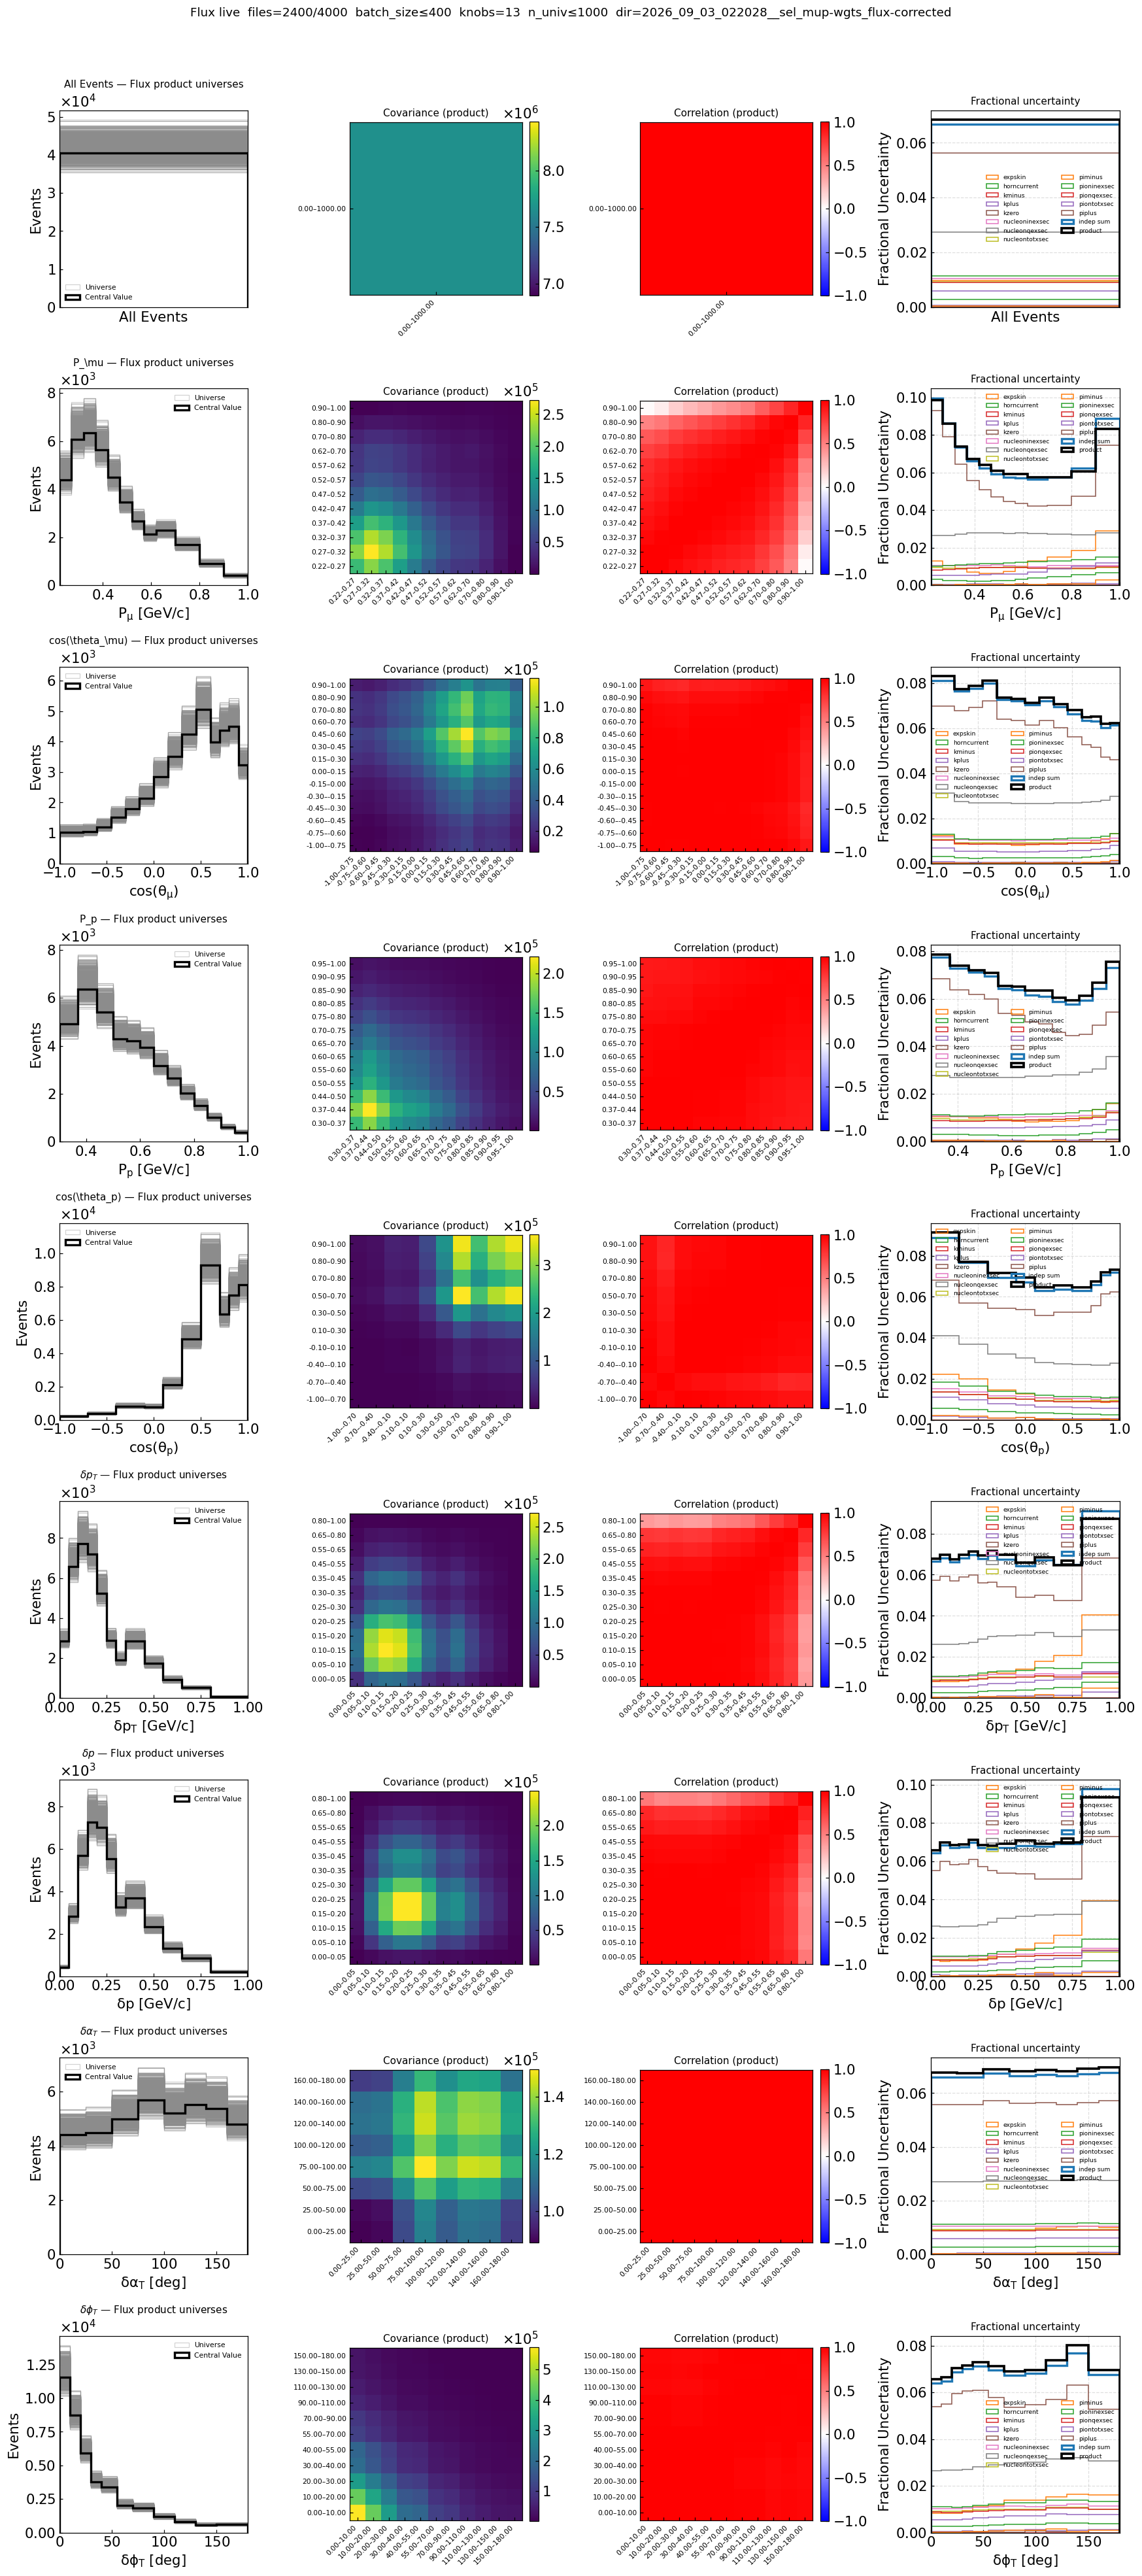

Flux live  files=400/4000  batch_size≤400  knobs=13  n_univ≤1000  dir=2026_09_03_022028__sel_mup-wgts_flux-corrected
[multisim-live] batch2/10(400 files) loaded evt rows=7,475 in 139.9s — accumulating…
[multisim-live] batch2/10(400 files) accumulate done in 4712.1s
Flux live  files=800/4000  batch_size≤400  knobs=13  n_univ≤1000  dir=2026_09_03_022028__sel_mup-wgts_flux-corrected
[multisim-live] batch3/10(400 files) loaded evt rows=7,334 in 126.3s — accumulating…
[multisim-live] batch3/10(400 files) accumulate done in 4254.3s
Flux live  files=1200/4000  batch_size≤400  knobs=13  n_univ≤1000  dir=2026_09_03_022028__sel_mup-wgts_flux-corrected
[multisim-live] batch4/10(400 files) loaded evt rows=7,396 in 138.8s — accumulating…
[multisim-live] batch4/10(400 files) accumulate done in 5123.4s
Flux live  files=1600/4000  batch_size≤400  knobs=13  n_univ≤1000  dir=2026_09_03_022028__sel_mup-wgts_flux-corrected
[multisim-live] batch5/10(400 files) loaded evt rows=7,268 in 133.2s — accumulating

In [ ]:
live_cfg = LiveMultisimConfig(
    df_dir=DF_DIR,
    syst_name=SYST_NAME,
    flux_knob_groups=FLUX_KNOB_GROUPS,
    n_universe=N_UNIVERSE,
    max_files=MAX_FILES,
    files_per_batch=FILES_PER_BATCH,
    update_every_n_files=UPDATE_EVERY_N_FILES,
    var_set="final",
    plot_var_names=PLOT_VAR_NAMES,
    accumulate_var_names=ACCUMULATE_VAR_NAMES,
    accumulate_total=ACCUMULATE_TOTAL,
    show_in_notebook=SHOW_IN_NOTEBOOK,
    save_every_update=True,
    save_panel_png=True,
    work_dir=work_dir,
    plots_dir=plots_dir,
    univ_alpha=UNIV_ALPHA,
)

print(
    f"live_cfg: files_per_batch={live_cfg.files_per_batch}  "
    f"update_every_n_files={live_cfg.update_every_n_files}  "
    f"max_files={live_cfg.max_files}"
)

result = run_live_accumulate(live_cfg)
print("payload:", result.payload_path)
print("files done:", result.n_files_done, "/", result.n_files_total)
if result.failed:
    print("failures:", len(result.failed))
    for p, err in result.failed[:5]:
        print(" ", Path(p).name, err)


## Reload saved histcounts → cov / corr / uncertainties

Load ``accumulated_histcounts.pkl`` (from this run or a prior one). Uses the
saved ``analysis`` block (per-knob, indep fractional sum, product total) when
present, and re-plots distributions + matrices + multi-component fractional
uncertainties.


In [ ]:
# Point at the payload from the live run (override if reloading an older file).
PAYLOAD_PATH = str(result.payload_path) if "result" in dir() else path.join(
    work_dir, "accumulated_histcounts.pkl"
)

payload = load_payload(PAYLOAD_PATH)
print(
    f"loaded {PAYLOAD_PATH}\n"
    f"  syst={payload.get('syst_name')}  files={payload.get('n_files_done')}/"
    f"{payload.get('n_files_total')}  knobs={len(payload.get('knobs') or [])}\n"
    f"  created={payload.get('created')}"
)

var_configs = var_configs_from_payload(payload)
vc_by = {vc.var_save_name: vc for vc in var_configs}
packs = packs_from_payload(payload)
print(f"  vars with packs: {list(packs.keys())}")

makedirs(plots_dir, exist_ok=True)

In [ ]:
# Rebuild the multi-panel summary from saved counts
fig = make_accumulation_panel(
    payload["acc"],
    var_configs,
    status=(
        f"reloaded {payload.get('syst_name')}  "
        f"files={payload.get('n_files_done')}/{payload.get('n_files_total')}"
    ),
    plot_var_names=PLOT_VAR_NAMES,
    univ_alpha=UNIV_ALPHA,
    syst_label=payload.get("syst_name", SYST_NAME),
)
panel_png = path.join(plots_dir, "reloaded_accumulation_panel.png")
fig.savefig(panel_png, dpi=150, bbox_inches="tight")
plt.show()
print("saved", panel_png)

In [ ]:
# Per-variable plots: product universes + matrices + multi-component frac unc
SAVE_UTILS_PLOTS = True
SHOW_UTILS_PLOTS = True

plot_names = [n for n in PLOT_VAR_NAMES if n in packs]
syst_tag = payload.get("syst_name", SYST_NAME)

for vsn in plot_names:
    vc = vc_by[vsn]
    a = packs[vsn]
    univ = a["univ_events"]          # product total when available
    cv = a["cv_events"]
    matrix_pack = a["matrix_pack"]   # product cov/corr when available
    stem = path.join(plots_dir, f"{vsn}-{syst_tag}")

    # --- product-total universes ---
    plot_univ_hists(
        univ,
        cv,
        f"{syst_tag}-product",
        vc,
        plot=SHOW_UTILS_PLOTS,
        save_fig=SAVE_UTILS_PLOTS,
        save_name=f"{stem}-universes-product",
        ax_titles=["", "Events", f"{getattr(vc, 'var_plot_name', vsn)} — {syst_tag} product"],
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    draw_univ_hists_on_ax(
        ax,
        univ,
        cv,
        vc,
        univ_alpha=UNIV_ALPHA,
        title=f"{getattr(vc, 'var_plot_name', vsn)} — {syst_tag} product",
    )
    if SAVE_UTILS_PLOTS:
        fig.savefig(f"{stem}-universes-product-lightalpha.png", dpi=150, bbox_inches="tight")
    if SHOW_UTILS_PLOTS:
        plt.show()
    else:
        plt.close(fig)

    for matrix_type, cmap in (("cov", "viridis"), ("cov_frac", "viridis"), ("corr", "bwr")):
        plot_heatmap(
            matrix_pack[matrix_type],
            vc.bins,
            plot_labels=[
                vc.var_labels[0] if vc.var_labels else vsn,
                vc.var_labels[0] if vc.var_labels else vsn,
                f"{matrix_type.capitalize()} (product)",
            ],
            plot=SHOW_UTILS_PLOTS,
            save_fig=SAVE_UTILS_PLOTS,
            save_name=f"{stem}-{matrix_type}-product",
            cmap=cmap,
        )

    # --- frac unc: each knob + indep sum + product ---
    series = frac_series_from_analysis(a)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    draw_frac_unc_on_ax(
        ax,
        series,
        vc,
        title=f"{getattr(vc, 'var_plot_name', vsn)} — {syst_tag} frac. unc.",
    )
    if SAVE_UTILS_PLOTS:
        fig.savefig(f"{stem}-frac_unc-breakdown.png", dpi=150, bbox_inches="tight")
    if SHOW_UTILS_PLOTS:
        plt.show()
    else:
        plt.close(fig)

    plot_frac_unc(
        [frac for _, frac in series],
        vc,
        plot_labels=["", "", f"{getattr(vc, 'var_plot_name', vsn)} — {syst_tag} frac. unc."],
        legends=[lab for lab, _ in series],
        plot=SHOW_UTILS_PLOTS,
        save_fig=SAVE_UTILS_PLOTS,
        save_name=f"{stem}-frac_unc",
    )

print("done — plots under", plots_dir)

